## 1. Imports & Setup

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Load the Dataset

In [24]:
df = pd.read_csv("../data/processed/amazon_reviews_clean.csv")

print(df.shape)
df.head()

(34626, 12)


,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment,id,keys,asins
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,This product so far has not disappointed. My c...,Kindle,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,great for beginner or experienced person. Boug...,very fast,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2


In [25]:
df.info()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34626 entries, 0 to 34625
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 27867 non-null  object 
 1   brand                34626 non-null  object 
 2   categories           34626 non-null  object 
 3   reviews.rating       34626 non-null  float64
 4   reviews.text         34626 non-null  object 
 5   reviews.title        34620 non-null  object 
 6   reviews.numHelpful   34131 non-null  float64
 7   reviews.doRecommend  34066 non-null  object 
 8   sentiment            34626 non-null  object 
 9   id                   34626 non-null  object 
 10  keys                 34626 non-null  object 
 11  asins                34624 non-null  object 
dtypes: float64(2), object(10)
memory usage: 3.2+ MB


name                   6759
brand                     0
categories                0
reviews.rating            0
reviews.text              0
reviews.title             6
reviews.numHelpful      495
reviews.doRecommend     560
sentiment                 0
id                        0
keys                      0
asins                     2
dtype: int64

## 3. Feature Selection

The objective is to group products into meaningful meta-categories based on textual similarity and product characteristics. Therefore, only descriptive variables are retained while identifiers and review metadata are excluded.  

In [26]:
cluster_df = df[
    [
        "name",
        "categories",
        "reviews.text",
    ]
].copy()

In [27]:
cluster_df["name"] = cluster_df["name"].fillna("")

In [28]:
cluster_df["cluster_text"] = (
    cluster_df["name"]
    + " "
    + cluster_df["categories"]
    + " "
    + cluster_df["reviews.text"]
)

## 4. Text Preprocessing
    - Build the Clustering Corpus

K-Means cannot work directly with text data. Therefore, the product information is converted into a numerical representation using TF-IDF (Term Frequency–Inverse Document Frequency).

TF-IDF assigns higher importance to words that are frequent within a document but uncommon across the dataset, helping distinguish different product types.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
tfidf = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=5,
    max_df=0.90
)


+ stop_words="english" → removes common words like the, is, and.
+ lowercase=True → treats "Tablet" and "tablet" as the same word.
+ min_df=5 → ignores words appearing in fewer than 5 documents (reduces noise).
+ max_df=0.90 → ignores extremely common words.


## 5. TF-IDF Vectorization

In [31]:
X_tfidf = tfidf.fit_transform(cluster_df["cluster_text"])

print(X_tfidf.shape)

(34626, 4310)


In [32]:
print(f"Vocabulary size: {len(tfidf.get_feature_names_out()):,}")

Vocabulary size: 4,310


In [33]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['00' '000' '10' '100' '1000' '1080' '1080p' '10x' '11' '12' '120' '128'
 '128gb' '13' '139' '14' '15' '150' '16' '16g' '16gb' '17' '179' '18'
 '180' '19' '199' '1st' '1yr' '20' '200' '2011' '2012' '2013' '2014'
 '2015' '2016' '2017' '21' '22' '24' '25' '250' '29' '2gb' '2nd' '2yr'
 '30' '300' '300ppi']


## 6. 6. Dimensionality Reduction (Truncated SVD)

TF-IDF creates a very high-dimensional and sparse representation of the text. High dimensionality can reduce the effectiveness and efficiency of K-Means clustering.

To obtain a compact representation while preserving the main semantic information, Truncated Singular Value Decomposition (Truncated SVD), also known as Latent Semantic Analysis (LSA), is applied.

In [34]:
from sklearn.decomposition import TruncatedSVD

In [35]:
svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_reduced = svd.fit_transform(X_tfidf)

In [36]:
print("Original shape:", X_tfidf.shape)
print("Reduced shape:", X_reduced.shape)

Original shape: (34626, 4310)
Reduced shape: (34626, 100)


## 7. Choosing the Number of Clusters

The optimal number of clusters is evaluated using two complementary methods:

- **Elbow Method**, which measures the within-cluster sum of squares (inertia).
- **Silhouette Score**, which evaluates how well separated the clusters are.

The assignment suggests grouping products into 4–6 meaningful meta-categories, so this range will be explored.

In [37]:
#Evaluate K = 2–10
inertia = []
silhouette = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_reduced)

    inertia.append(kmeans.inertia_)

    silhouette.append(
        silhouette_score(X_reduced, labels)
    )

####  - Elbow Method

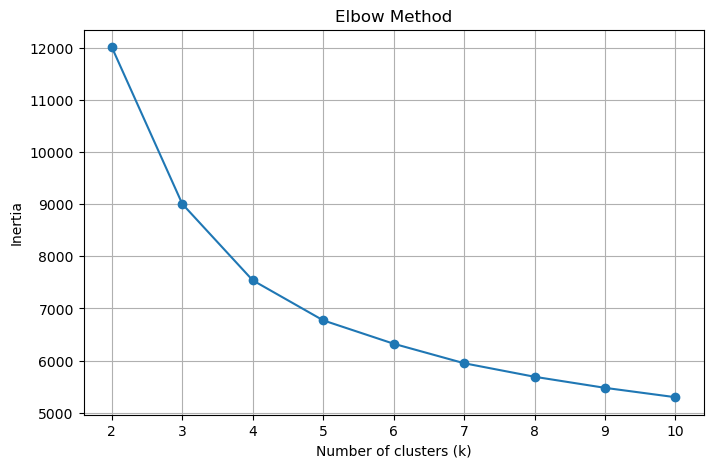

In [38]:
#Elbow Plot
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

#### - Silhouette Analysis

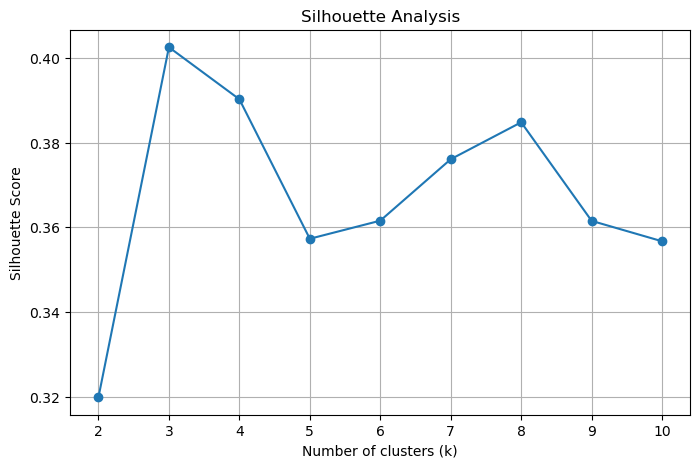

In [39]:
#Silhouette Plot
plt.figure(figsize=(8,5))

plt.plot(k_values, silhouette, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

## Choosing the Number of Clusters

Two complementary evaluation methods were used to determine the optimal number of clusters.

The Elbow Method indicates that the reduction in inertia begins to level off after **k = 4**, suggesting that additional clusters provide only marginal improvements in compactness.

The Silhouette Analysis achieves its highest score at **k = 3 (0.403)**. However, **k = 4** also achieves a high silhouette score (**0.390**), indicating well-separated clusters while remaining consistent with the elbow criterion.

Considering both evaluation methods together, **k = 4** was selected as the final model because it provides a good balance between cluster quality, compactness, and interpretability.

## 8. Final K-Means Model

Based on the Elbow Method and Silhouette Analysis, the final K-Means model was trained using **4 clusters**.

The resulting cluster labels are assigned to each product review and will be analyzed in the following sections to identify meaningful product meta-categories.

In [40]:
#8.1 Train the final model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

cluster_df["cluster"] = kmeans.fit_predict(X_reduced)

cluster_df.head()

,name,categories,reviews.text,cluster_text,cluster
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",This product so far has not disappointed. My c...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",0
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",great for beginner or experienced person. Boug...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",0
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",Inexpensive tablet for him to use and learn on...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",0
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",I've had my Fire HD 8 two weeks now and I love...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",0
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",I bought this for my grand daughter when she c...,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",0


In [41]:
#8.2 Cluster sizes
cluster_df["cluster"].value_counts().sort_index()

cluster
0    17400
1     4908
2     5056
3     7262
Name: count, dtype: int64

## 9. Cluster Interpretation

Since K-Means produces numerical cluster labels without semantic meaning, each cluster is analyzed by inspecting its most frequent product names, product categories, and representative reviews.

This qualitative analysis allows meaningful names to be assigned to the discovered product groups.

In [44]:
# 9.1 Cluster Sizes
cluster_sizes = cluster_df["cluster"].value_counts().sort_index()

display(cluster_sizes)

cluster
0    17400
1     4908
2     5056
3     7262
Name: count, dtype: int64

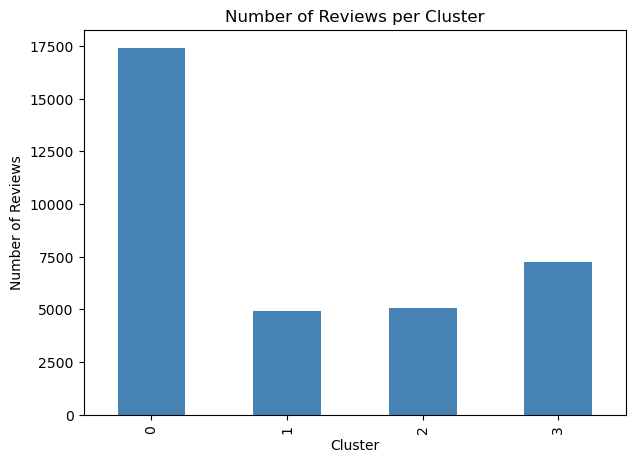

In [46]:
# 8.3 Visualize the distribution
plt.figure(figsize=(7,5))

cluster_df["cluster"].value_counts().sort_index().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Number of Reviews per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Reviews")

plt.show()

In [47]:
# 9.2 Most common product names
for c in sorted(cluster_df["cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"Cluster {c}")
    print('='*60)

    print(
        cluster_df.loc[
            cluster_df["cluster"] == c,
            "name"
        ].value_counts().head(10)
    )


Cluster 0
name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                          10752
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta                          2814
Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case                                          1685
Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,                                         976
Echo (White),,,\r\nEcho (White),,,                                                                                411
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black                                              307
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta                           146
                                                                                                                  135
Amazon Kindle Paperwhite - eBook reader 

In [48]:
# 9.3 Most common categories
for c in sorted(cluster_df["cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"Cluster {c}")
    print('='*60)

    print(
        cluster_df.loc[
            cluster_df["cluster"] == c,
            "categories"
        ].value_counts().head(10)
    )


Cluster 0
categories
Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys                                                                                 10966
Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets                                                                                                                                             2814
Tablets,Fire Tablets,Computers & Tablets,All Tablets                                                                                                                                                                        1545
Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets                                                                                                                              1038
Electronics Features,Fire Tablets,Computers & Tablets,Tablets,All Tablets,Comp

In [49]:
# 9.4 Representative reviews
for c in sorted(cluster_df["cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"Cluster {c}")
    print('='*60)

    sample = cluster_df.loc[
        cluster_df["cluster"] == c,
        "reviews.text"
    ].sample(5, random_state=42)

    for review in sample:

        print("-"*50)
        print(review)


Cluster 0
--------------------------------------------------
Bad graphics. Ugly design. Good for the price. Not recommended.
--------------------------------------------------
Love this tablet. I got it for my niece to watch her videos on and educational videos. She doesn't put it down. The battery life is awesome.
--------------------------------------------------
This is a newer version of the Fire I had previously and I love it. I like the camera. This version is lighter than the other. It is taking me a while to learn the differences but most of them are improvements.
--------------------------------------------------
Great product. Love the Amazon ecosystem. The Freetime subscription is a must
--------------------------------------------------
I got this for $35 during Black Friday. Since I've had it, I noticed that the battery life does not last very long. I have to charge it at least once a day. At first, I thought that I may have a faulty tablet, but I looked on Amazon's websi

## 10. Cluster Visualization

To visually inspect the clustering results, the TF-IDF representation is projected into two dimensions using Truncated Singular Value Decomposition (Truncated SVD).

This visualization is intended for interpretation only and does not affect the clustering model.

In [ ]:
# 10.1 Reduce to two dimensions
svd_vis = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_vis = svd_vis.fit_transform(X_tfidf)

In [51]:
# 10.2 Create a visualization DataFrame
vis_df = pd.DataFrame({
    "Component 1": X_vis[:, 0],
    "Component 2": X_vis[:, 1],
    "Cluster": cluster_df["cluster"]
})

vis_df.head()

,Component 1,Component 2,Cluster
0,0.373054,-0.255188,0
1,0.425902,-0.303904,0
2,0.326120,-0.234547,0
3,0.245901,-0.161291,0
4,0.243711,-0.157928,0


In [54]:

# Replace numeric cluster IDs with descriptive names
cluster_names = {
    0: "Fire Tablets",
    1: "Kindle E-Readers",
    2: "Fire TV & Streaming",
    3: "Echo & Smart Home"
}

vis_df["Cluster"] = vis_df["Cluster"].map(cluster_names)

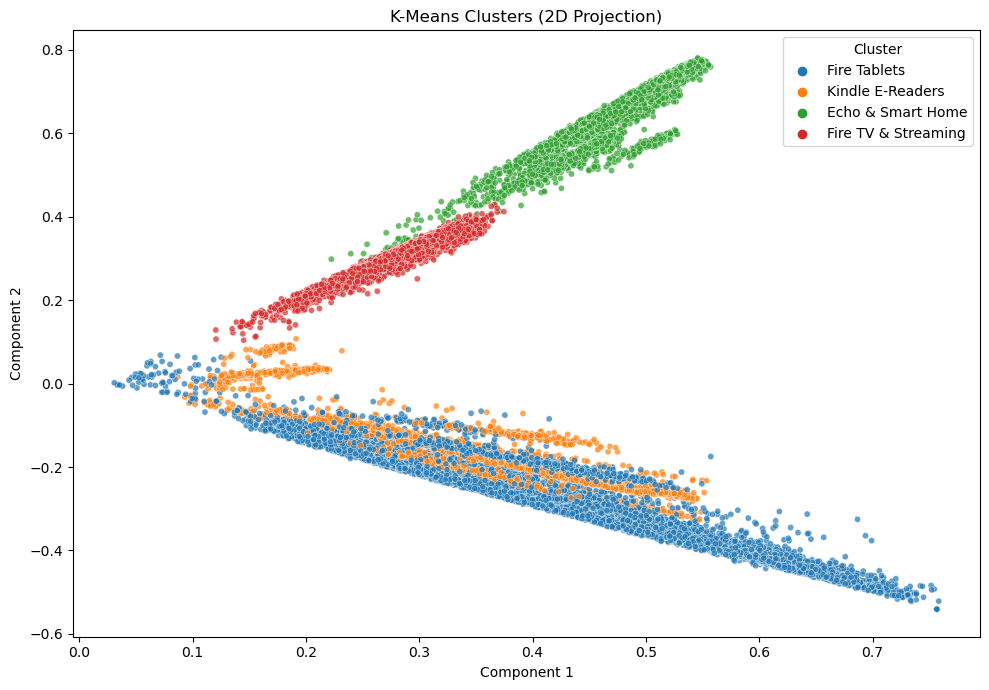

In [55]:
# 10.3 Scatter plot
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=vis_df,
    x="Component 1",
    y="Component 2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7,
    s=20
)

plt.title("K-Means Clusters (2D Projection)")
plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

## 11. Conclusions

### Findings

This project successfully applied **K-Means clustering** to group Amazon product reviews into four meaningful product meta-categories.

The clustering pipeline combined textual information from the **product name**, **product category**, and **review text**, which was transformed into TF-IDF features and reduced using **Truncated Singular Value Decomposition (Truncated SVD)** before applying K-Means.

The optimal number of clusters was selected by considering both the **Elbow Method** and the **Silhouette Score**. Although the highest silhouette score was obtained with three clusters, four clusters were selected because they provided a good balance between cluster quality and interpretability while remaining consistent with the project objectives.

The resulting clusters correspond to clear Amazon product families:

- Fire Tablets
- Kindle E-Readers
- Fire TV & Streaming Devices
- Echo & Smart Home Devices

The visualization confirms that these product groups are well separated in the reduced feature space, indicating that the textual representation captures meaningful differences between product categories.

### Business Value

Grouping products into high-level categories simplifies the analysis of large review datasets and enables downstream applications such as:

- Product catalog organization
- Category-level customer feedback analysis
- Product recommendation systems
- Automatic review summarization by product family

### Limitations

The clustering quality depends heavily on the textual information available for each product. Some products have missing names or very short reviews, which can reduce the amount of semantic information available.

Additionally, the two-dimensional visualization is only an approximation of the high-dimensional feature space and should be used for interpretation rather than quantitative evaluation.

### Future Improvements

Potential improvements include:

- Experimenting with transformer-based sentence embeddings (e.g., Sentence-BERT) instead of TF-IDF.
- Comparing K-Means with other clustering algorithms such as Agglomerative Clustering or HDBSCAN.
- Enriching the product representation with additional metadata where appropriate.

## 12. Save the Model

The complete clustering pipeline is saved to disk so that new product reviews can be assigned to clusters without retraining the model.

The following components are stored:

- TF-IDF Vectorizer
- Truncated SVD
- K-Means Model

In [56]:
import joblib
import os

In [57]:
MODEL_PATH = "../models/kmeans"

os.makedirs(MODEL_PATH, exist_ok=True)

In [58]:
joblib.dump(tfidf, f"{MODEL_PATH}/tfidf_vectorizer.pkl")

joblib.dump(svd, f"{MODEL_PATH}/truncated_svd.pkl")

joblib.dump(kmeans, f"{MODEL_PATH}/kmeans_model.pkl")

['../models/kmeans/kmeans_model.pkl']

In [59]:
# Save the cluster names
cluster_names = {
    0: "Fire Tablets",
    1: "Kindle E-Readers",
    2: "Fire TV & Streaming",
    3: "Echo & Smart Home"
}

joblib.dump(cluster_names, f"{MODEL_PATH}/cluster_names.pkl")

['../models/kmeans/cluster_names.pkl']

In [60]:
os.listdir(MODEL_PATH)

['tfidf_vectorizer.pkl',
 'truncated_svd.pkl',
 'cluster_names.pkl',
 'kmeans_model.pkl']